<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/LENET5_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# data

In [6]:
import tensorflow
from tensorflow import keras
from keras.datasets import mnist
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, AveragePooling2D

In [7]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


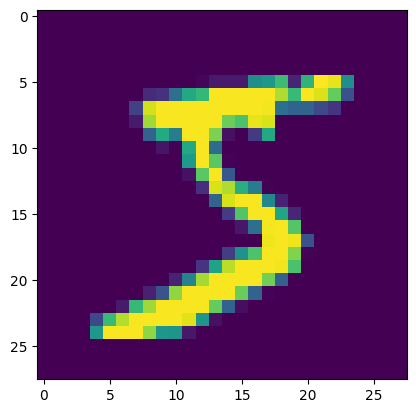

5


In [ ]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.show()
print(y_train[0])

In [ ]:
X_train[0].shape

(28, 28)

# LENET5

In [3]:
model = Sequential()

model.add(Conv2D(6,kernel_size = (5,5), padding = "valid", activation = "tanh", input_shape = (28, 28, 1))) # input shape = (28, 28, 1)
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = "valid"))

# model.add(Conv2D(6,kernel_size = (5,5), stride = (1,1), padding = "valid", activation = "tanh", input_shape = (28,28,1)))
# model.add(AveragePooling2D(pool_size = (2,2), stride = (2,2), padding = "valid"))

model.add(Conv2D(16,kernel_size = (5,5), padding = "valid", activation = "tanh")) # input shape = (24, 24, 32)
model.add(AveragePooling2D(pool_size = (2,2), strides = 2, padding = "valid"))

model.add(Flatten())

model.add(Dense(120, activation = "tanh"))
model.add(Dense(84, activation = "tanh"))
model.add(Dense(10, activation = "softmax"))

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer = "Adam",loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
history = model.fit(X_train, y_train, epochs = 10, validation_data = (X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.9009 - loss: 0.3397 - val_accuracy: 0.9728 - val_loss: 0.0858
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.9777 - loss: 0.0729 - val_accuracy: 0.9829 - val_loss: 0.0533
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.9826 - loss: 0.0553 - val_accuracy: 0.9831 - val_loss: 0.0531
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.9859 - loss: 0.0450 - val_accuracy: 0.9842 - val_loss: 0.0526
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9877 - loss: 0.0361 - val_accuracy: 0.9839 - val_loss: 0.0489
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9908 - loss: 0.0291 - val_accuracy: 0.9848 - val_loss: 0.0475
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9914 - loss: 0.0258 - val_accuracy: 0.9884 - val_loss: 0.0377
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.9930 -

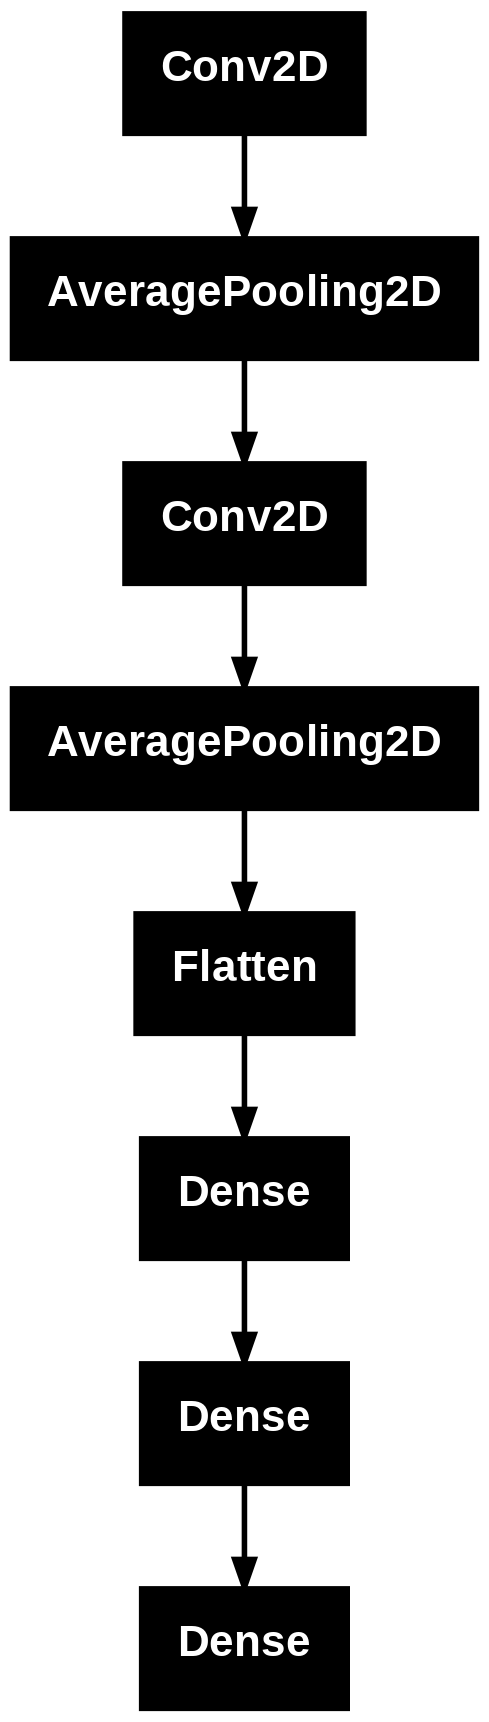

In [5]:
from keras.utils import plot_model

plot_model(model, to_file='lenet.png')

# eval

In [15]:
y_hat = (model.predict(X_test)).argmax(axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [16]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_hat)

0.9845

In [17]:
# MLP had accuracy of 0.9771

In [18]:
print(f"predicted: {y_hat[0]:6.0f} actual: {y_test[0]:6.0f}")

predicted:      7 actual:      7


**WAYS TO IMPROVE -**

 - activation - relu
 - batch norm
 - dropout
 - more epochs & early stopping
 - lr scheduling and optimizer checking using keras-tuner
 - more hyperparameter tuning using keras-tuner



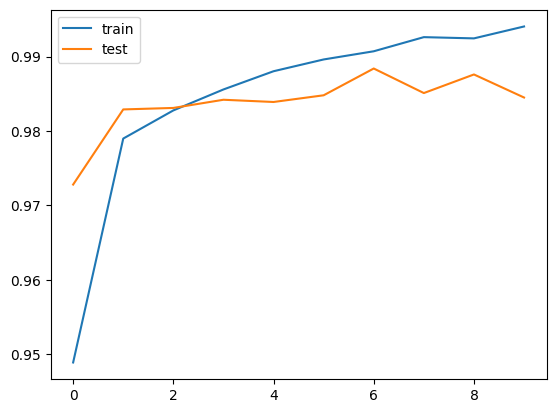

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["train", "test"])
plt.show()

# Extras
**TODO -**

1. CNN from scratch
2. maybe visualize the middle layers
3. try different archs

## visualizing filters -

In [20]:
weights = model.get_weights()
for i in range(len(weights)):
    print(weights[i].shape)

(5, 5, 1, 6)
(6,)
(5, 5, 6, 16)
(16,)
(256, 120)
(120,)
(120, 84)
(84,)
(84, 10)
(10,)




```
(5, 5, 1, 6) -------- layer 1 weights
(6,) ---------------- layer 1 biases
(5, 5, 6, 16) ------- layer 2 w
(16,) --------------- layer 2 b
(256, 120) ---------- layer 3 w (fully connected)
(120,) -------------- layer 3 b
(120, 84) ----------- layer 4 w
(84,)  -------------- layer 4 b
(84, 10) ------------ layer 5 w
(10,) --------------- layer 5 b
```



In [21]:
type(weights[1])

numpy.ndarray

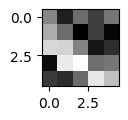

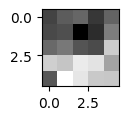

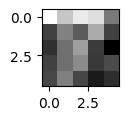

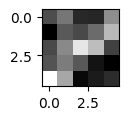

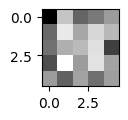

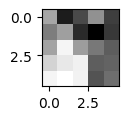

In [45]:
# layer 1 filters
for i in range(6):
  for j in range(1):
    plt.figure(figsize = (1,1))
    # plt.imshow(weights[0][:,:,j,i]+weights[1][i])
    plt.imshow(weights[0][:,:,j,i], cmap = "gray")
    plt.show()

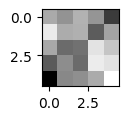

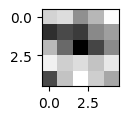

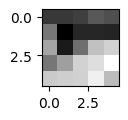

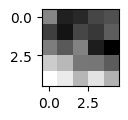

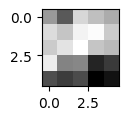

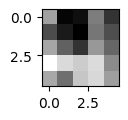

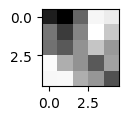

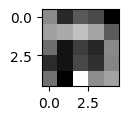

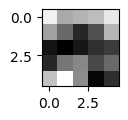

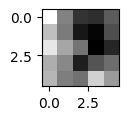

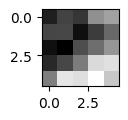

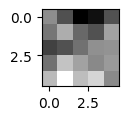

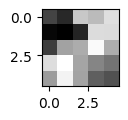

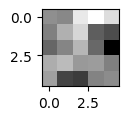

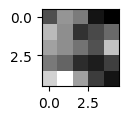

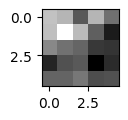

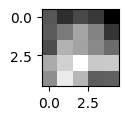

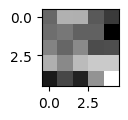

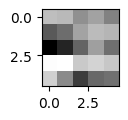

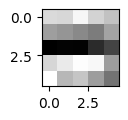

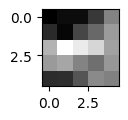

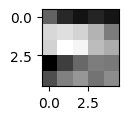

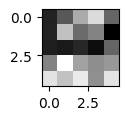

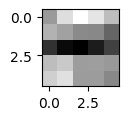

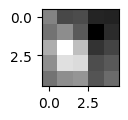

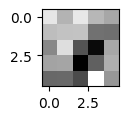

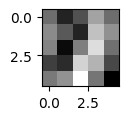

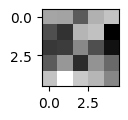

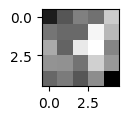

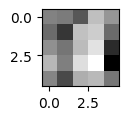

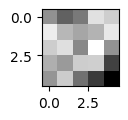

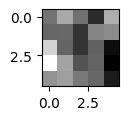

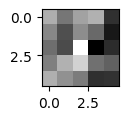

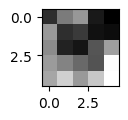

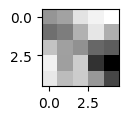

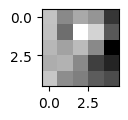

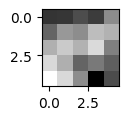

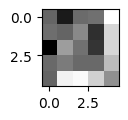

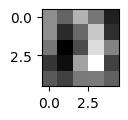

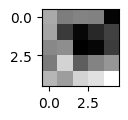

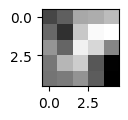

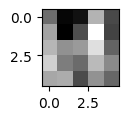

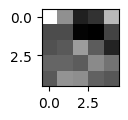

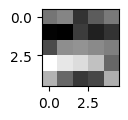

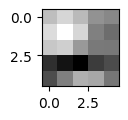

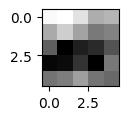

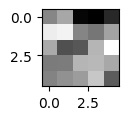

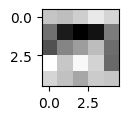

In [46]:
# layer 2 filters
for i in range(8): # only 8 out of 16
  for j in range(6):
    plt.figure(figsize = (1,1))
    plt.imshow(weights[2][:,:,j,i], cmap = "gray")
    plt.show()

## visualizing intermediate images (features)

In [35]:
# Get the output of the first convolutional layer
intermediate_layer_model = Sequential()
for layer in model.layers[:2]: # Include up to the first AveragePooling2D layer
    intermediate_layer_model.add(layer)

intermediate_output = intermediate_layer_model.predict(X_test[3].reshape(1, 28, 28, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


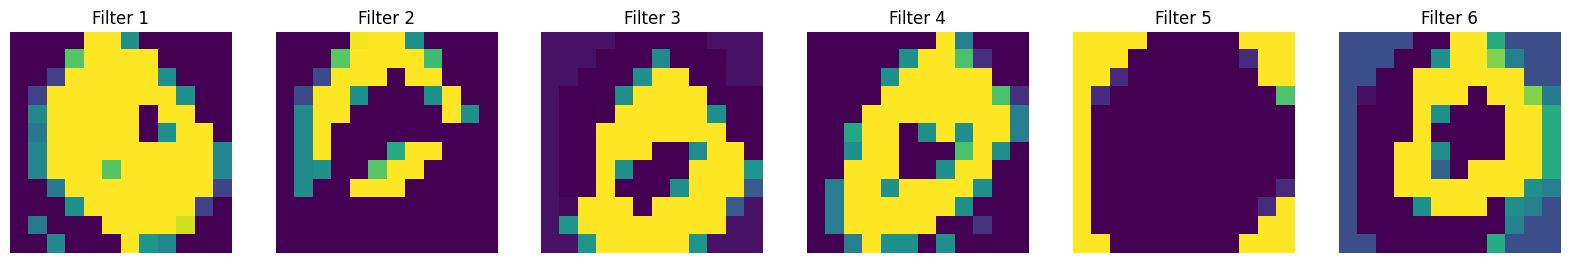

In [36]:
# Visualize the output of each filter in the first convolutional layer
fig, axes = plt.subplots(1, intermediate_output.shape[-1], figsize=(20, 5))
for i in range(intermediate_output.shape[-1]):
    # To show only positive edges, use: cmap='viridis' , vmin=0
    # To show only negative edges, use: cmap='plasma' , vmax=0
    axes[i].imshow(intermediate_output[0, :, :, i], cmap='viridis', vmin=0)
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')
plt.show()

In [37]:
# Get the output of the first convolutional layer
intermediate_layer_model = Sequential()
for layer in model.layers[:4]: # Include up to the second AveragePooling2D layer (Conv2D, AvgPool2D, Conv2D, AvgPool2D)
    intermediate_layer_model.add(layer)

intermediate_output = intermediate_layer_model.predict(X_test[3].reshape(1, 28, 28, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


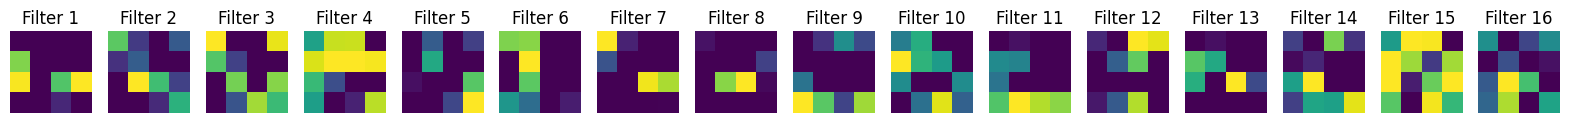

In [38]:
# Visualize the output of each filter in the second convolutional layer
fig, axes = plt.subplots(1, intermediate_output.shape[-1], figsize=(20, 10)) # Adjusted figsize for more filters
for i in range(intermediate_output.shape[-1]):
    # To show only positive edges, use: cmap='viridis' , vmin=0
    # To show only negative edges, use: cmap='plasma' , vmax=0
    axes[i].imshow(intermediate_output[0, :, :, i], cmap='viridis', vmin=0)
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')
plt.show()